# Progetto Machine Learning: Cupid's Algorithm

In questo notebook costruiamo un modello di **classificazione binaria** che prova a prevedere se due persone (Persona A e Persona B) sono **compatibili** oppure no, partendo dai loro dati anagrafici e dai loro tratti di personalità.

Il percorso è diviso in questi passaggi:

1. Importare i dati
2. Osservare il dataset
3. Training e Test (con creazione di nuove variabili)
4. Data Exploration
5. Data preprocessing e Pipeline di elaborazione (con verifica sperimentale delle variabili scelte)
6. Definizione e Addestramento del modello
7. Validazione e risultati
8. Analisi degli errori
9. Ottimizzazione degli Iperparametri (Random Forest)
10. Valutazione Finale sul Test Set
11. Curve Precision/Recall e soglia di decisione
12. Confronto con una Rete Neurale (MLP) e ottimizzazione dei suoi iperparametri
13. Valutazione finale comparativa


## 1. Importare i dati

Iniziamo preparando gli strumenti di lavoro: importiamo le librerie standard di Data
Science (Pandas, Seaborn, Matplotlib) e usiamo `kagglehub` per scaricare in automatico
l'ultima versione del dataset "Cupid's Algorithm" da Kaggle.

In [ ]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scarichiamo l'ultima versione del dataset
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")
print("Percorso del dataset:", path)

archivio = os.listdir(path)
print("File trovati:", archivio)

csv_path = os.path.join(path, archivio[0])

Using Colab cache for faster access to the 'cupids-algorithm' dataset.
Percorso del dataset: /kaggle/input/cupids-algorithm
File trovati: ['cupid_algorithm_dataset.csv']


**Cosa abbiamo ottenuto:** il dataset è stato scaricato correttamente e contiene un
unico file, `cupid_algorithm_dataset.csv`, che useremo per tutto il progetto.

## 2. Osservare il dataset

Prima di lavorare sul codice, diamo un'occhiata veloce alla struttura dei dati con
`.head()`. Questo ci permette di vedere i primi profili delle coppie (Persona A e
Persona B) e i loro tratti.

In [ ]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


**Cosa abbiamo ottenuto:** il dataset ha 30 colonne in totale, che includono dati
demografici (età, istruzione, luogo di residenza), tratti psicologici (apertura,
estroversione, gradevolezza, ecc.) sia per la Persona A che per la Persona B, e le
variabili che vogliamo prevedere (compatibilità, punteggio di compatibilità, durata
della relazione).

## 3. Training e Test

Seguendo le buone pratiche di Machine Learning, separiamo subito il 20% dei dati come
"Test Set", **prima** di fare qualsiasi altra elaborazione. Questo è fondamentale per
evitare il *Data Leakage*: il modello deve imparare solo dal Training Set e restare
all'oscuro dei dati di test fino alla valutazione finale.

Togliamo dalle variabili di input (`X`) l'identificativo della coppia (`pair_id`, che
non ha alcun significato predittivo) e le tre variabili che vogliamo prevedere. In
questo notebook usiamo solo il target di classificazione binaria (`compatible`); le
altre due variabili di regressione restano definite ma non vengono utilizzate più
avanti.

In [ ]:
from sklearn.model_selection import train_test_split

# Rimuoviamo l'identificativo della coppia e le variabili che vogliamo prevedere
X = df.drop(["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"], axis=1)

# Definiamo i target possibili (in questo notebook usiamo solo quello di classificazione)
y_classificazione = df["compatible"]
y_regressione_1 = df["compatibility_score"]
y_regressione_2 = df["relationship_longevity_months"]

# Separiamo il 20% dei dati come Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y_classificazione, test_size=0.2, random_state=42)

X_train.info()
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

Abbiamo deciso di creare nuove variabili a partire da quelle esistenti, invece di
usare direttamente i valori grezzi di ciascun partner. L'idea è che ciò che conta per
la compatibilità non è tanto il valore assoluto di un tratto in A o in B, ma quanto
sono simili o diversi tra loro:

- **age_diff / career_ambition_diff**: differenza di età e di ambizione professionale.
- Una **differenza** analoga per ogni tratto di personalità (apertura, estroversione,
  gradevolezza, coscienziosità, cronotipo, spontaneità, espressività emotiva).
- Tre variabili binarie di **somiglianza** (`same_location`, `same_career_field`,
  `same_love_language`), che valgono 1 se i due partner condividono la stessa
  categoria e 0 altrimenti.

Calcoliamo queste variabili sia sul Training Set sia sul Test Set, usando sempre le
stesse formule, e poi lavoriamo su una copia del Training Set per non rischiare di
modificare per errore i dati originali.


In [ ]:
# Differenze per tutti i tratti di personalità (non solo età e ambizione)
tratti_personalita = [
    "openness", "extraversion", "agreeableness", "conscientiousness",
    "chronotype", "spontaneity", "emotional_expressiveness", "age","career_ambition"
]

for tratto in tratti_personalita:
    X_train[f"{tratto}_diff"] = abs(X_train[f"a_{tratto}"] - X_train[f"b_{tratto}"])
    X_test[f"{tratto}_diff"] = abs(X_test[f"a_{tratto}"] - X_test[f"b_{tratto}"])

# Variabili binarie di somiglianza per le categorie testuali
X_train["same_location"] = (X_train["a_location"] == X_train["b_location"]).astype(int)
X_test["same_location"] = (X_test["a_location"] == X_test["b_location"]).astype(int)

X_train["same_career_field"] = (X_train["a_career_field"] == X_train["b_career_field"]).astype(int)
X_test["same_career_field"] = (X_test["a_career_field"] == X_test["b_career_field"]).astype(int)

X_train["same_love_language"] = (X_train["a_love_language"] == X_train["b_love_language"]).astype(int)
X_test["same_love_language"] = (X_test["a_love_language"] == X_test["b_love_language"]).astype(int)

cupid_class = X_train.copy()

**Cosa abbiamo ottenuto:** il Training Set contiene 80.000 coppie e, dopo aver
aggiunto tutte le nuove variabili di differenza e somiglianza, passiamo da 26 a 38
colonne di input.


## 4. Data Exploration

Analizziamo la qualità dei dati con `.info()` (per controllare valori mancanti) e
`.describe()` (per vedere i range, ad esempio le età vanno da 18 a 55 anni). Poi
usiamo grafici per capire meglio la forma dei dati: gli **istogrammi** mostrano come
si distribuisce ogni variabile, mentre la **matrice di correlazione** (heatmap) ci
mostra quali tratti sono legati tra loro.

In [ ]:
cupid_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   a_age                          80000 non-null  int64  
 1   a_education                    80000 non-null  int64  
 2   a_location                     80000 non-null  object 
 3   a_career_field                 80000 non-null  object 
 4   a_career_ambition              80000 non-null  float64
 5   a_openness                     80000 non-null  float64
 6   a_extraversion                 80000 non-null  float64
 7   a_agreeableness                80000 non-null  float64
 8   a_conscientiousness            80000 non-null  float64
 9   a_chronotype                   80000 non-null  float64
 10  a_spontaneity                  80000 non-null  float64
 11  a_love_language                80000 non-null  object 
 12  a_emotional_expressiveness     80000 non-null  

In [ ]:
cupid_class.describe()

,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,a_emotional_expressiveness,...,agreeableness_diff,conscientiousness_diff,chronotype_diff,spontaneity_diff,emotional_expressiveness_diff,age_diff,career_ambition_diff,same_location,same_career_field,same_love_language
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,36.554075,2.951087,0.496328,0.499946,0.499847,0.500735,0.498768,0.499447,0.500225,0.499566,...,0.256937,0.256826,0.258706,0.260716,0.260302,12.650263,0.198389,0.397838,0.101462,0.198825
std,10.965604,1.117647,0.175067,0.223542,0.224494,0.224002,0.223235,0.224856,0.226442,0.226323,...,0.184074,0.183924,0.185665,0.186755,0.186308,8.953704,0.147380,0.489455,0.301942,0.399119
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,...,0.110000,0.110000,0.110000,0.110000,0.110000,5.000000,0.080000,0.000000,0.000000,0.000000
50%,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.220000,0.220000,0.220000,0.230000,0.230000,11.000000,0.170000,0.000000,0.000000,0.000000
75%,46.000000,4.000000,0.620000,0.670000,0.670000,0.670000,0.670000,0.670000,0.680000,0.670000,...,0.380000,0.380000,0.380000,0.380000,0.380000,19.000000,0.290000,1.000000,0.000000,0.000000
max,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.960000,0.970000,0.960000,0.980000,1.000000,37.000000,0.920000,1.000000,1.000000,1.000000


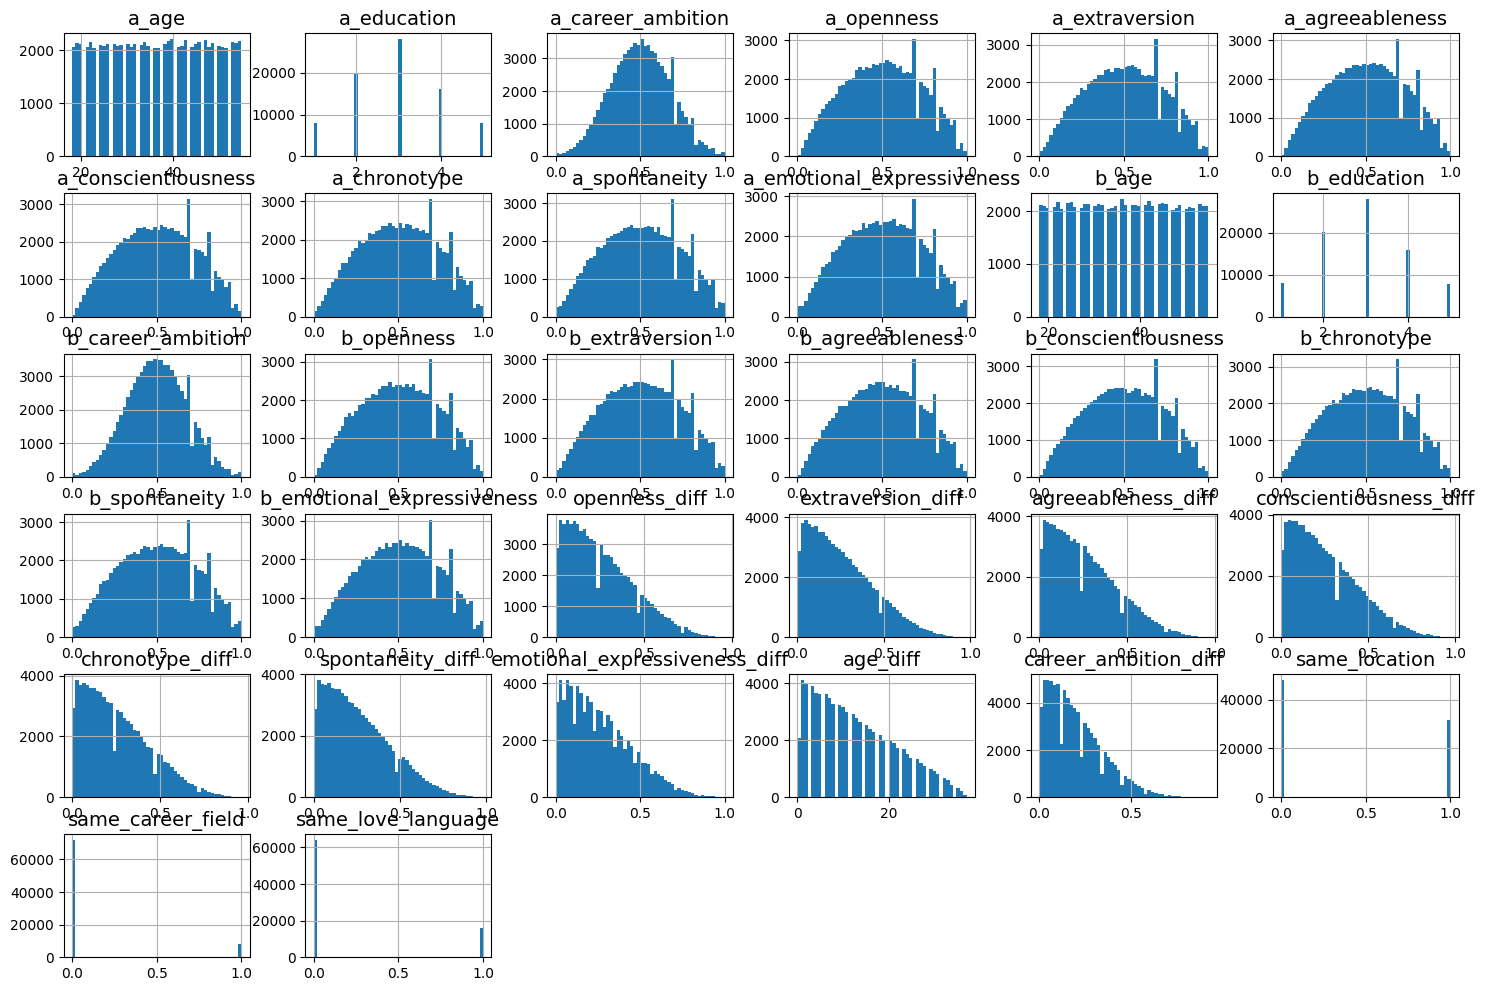

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

cupid_class.hist(bins=50, figsize=(18, 12))
plt.show()

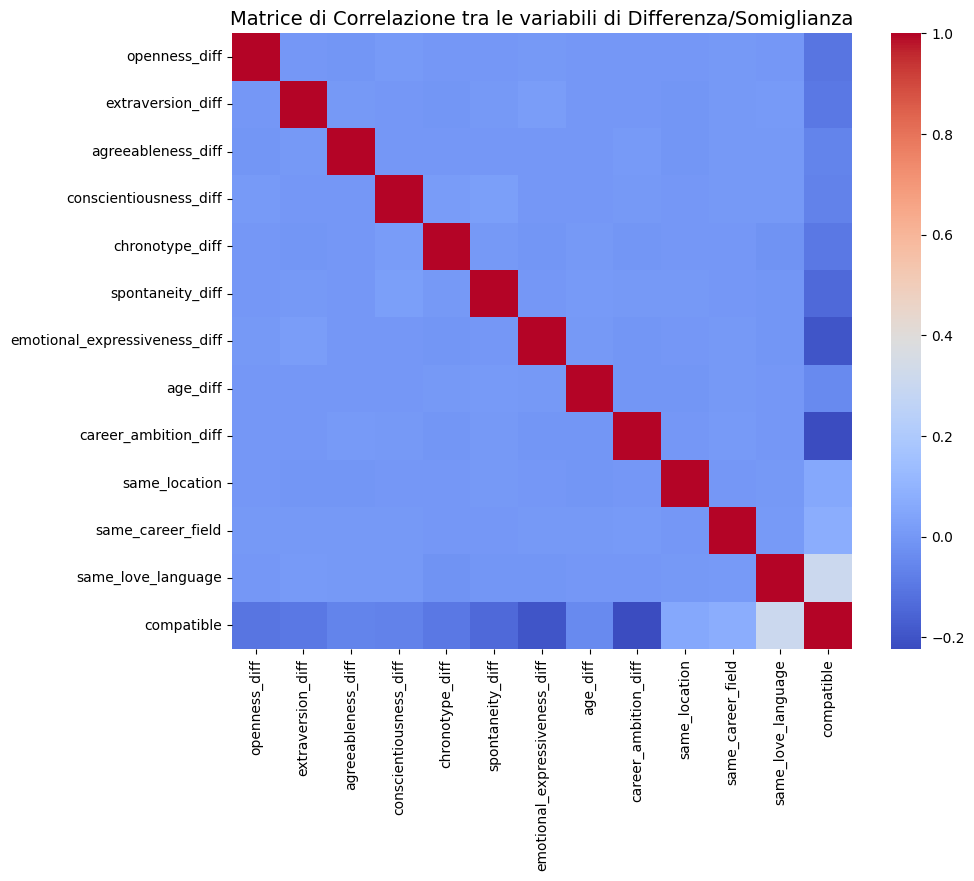

In [ ]:
# Filtriamo solo le variabili di differenza/somiglianza
colonne_diff = [col for col in cupid_class.columns if col.endswith("_diff") or col.startswith("same_")]

colonne_diff_con_target = colonne_diff + ["compatible"]
cupid_class_con_target = cupid_class[colonne_diff].copy()
cupid_class_con_target["compatible"] = y_train

corr_matrix_target = cupid_class_con_target.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_target, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di Correlazione tra le variabili di Differenza/Somiglianza")
plt.show()

**Cosa abbiamo ottenuto:** non ci sono valori mancanti in nessuna colonna. Le
variabili numeriche (età, tratti di personalità) hanno distribuzioni abbastanza
uniformi o a campana, senza valori anomali evidenti.

Abbiamo scelto di mostrare la matrice di correlazione solo per le variabili di
**differenza/somiglianza** tra i due partner (quelle che terminano in `_diff` o
iniziano con `same_`), includendo anche la variabile target `compatible`. In questo
modo il grafico risulta molto più leggibile rispetto a una heatmap con tutte le
colonne originali, e ci permette di rispondere direttamente alla domanda che ci
interessa: quali differenze tra Persona A e Persona B sono più legate alla
compatibilità?

Osservando l'ultima riga/colonna della matrice (quella di `compatible`), possiamo
individuare quali variabili `_diff` hanno il valore assoluto di correlazione più alto
(indipendentemente dal segno): un valore negativo indica che una differenza maggiore
è associata a una compatibilità più bassa (ad esempio ci aspettiamo questo per
`age_diff`), mentre un valore positivo indicherebbe l'effetto opposto. Le variabili
con correlazione vicina allo 0 sono invece quelle che, da sole, sembrano avere meno
peso nel determinare la compatibilità.

È importante sottolineare che questa analisi viene calcolata **solo sul Training
Set** e serve unicamente a noi per orientare l'esplorazione dei dati: non viene in
alcun modo passata al modello come informazione di input, quindi non comporta nessun
rischio di Data Leakage.

Inoltre, le correlazioni tra le variabili `_diff` stesse risultano generalmente
basse: questo è positivo, perché conferma che i dati non nascondono "scorciatoie"
sospette che il modello potrebbe sfruttare in modo scorretto (correlazioni spurie),
e che i dati seguono una logica psicologica plausibile.

## 5. Data preprocessing e Pipeline di elaborazione

I modelli di Machine Learning hanno bisogno che i dati siano tutti in un formato
numerico e su scale simili. In questa versione abbiamo deciso di usare **solo** le
variabili di differenza e somiglianza create nel passaggio precedente (niente valori
grezzi di A e B, niente variabili testuali): questo isola completamente l'idea che
conta la *relazione* tra i due partner, non l'identità di ciascuno.

Applichiamo quindi lo **StandardScaler** a tutte queste variabili (comprese quelle
binarie `same_...`), per portarle sulla stessa scala. Non serve `OneHotEncoder`
perché non restano più variabili testuali tra gli input del modello.

Prima di proseguire, però, verifichiamo che questa scelta sia davvero quella
migliore: nella cella seguente confrontiamo questa versione "solo differenze" con
una versione che include anche i valori grezzi di A e B, per vedere se questi ultimi
aggiungono informazione utile o no.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Solo le variabili di differenza/somiglianza, niente valori grezzi di A e B
num_features = [
    "age_diff", "career_ambition_diff",
    "openness_diff", "extraversion_diff", "agreeableness_diff",
    "conscientiousness_diff", "chronotype_diff", "spontaneity_diff",
    "emotional_expressiveness_diff"
]

cat_features = ["same_location", "same_career_field", "same_love_language"]

# Quando abbiamo fatto la unione delle variabili le categoriche le abbiamo convertito in binarie (0-1) quindi non é necesario fare il OneHotEncoder
preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features+ cat_features)
])

cupid_class_prepared = preprocessing.fit_transform(cupid_class)

# Ricostruiamo un DataFrame solo per controllare visivamente il risultato
cupid_class_prepared_df = pd.DataFrame(
    cupid_class_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=cupid_class.index
)
cupid_class_prepared_df.head(2)

,num__age_diff,num__career_ambition_diff,num__openness_diff,num__extraversion_diff,num__agreeableness_diff,num__conscientiousness_diff,num__chronotype_diff,num__spontaneity_diff,num__emotional_expressiveness_diff,num__same_location,num__same_career_field,num__same_love_language
75220,0.039061,-1.278261,0.067468,-0.473489,-0.743928,-0.689562,0.922600,0.424540,-1.236147,-0.812823,2.975879,-0.498163
48955,0.932551,-0.124773,0.285120,-0.257143,-0.037685,-0.472079,-0.046892,-1.021213,1.877005,-0.812823,-0.336035,-0.498163


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Variabili "complete": valori grezzi di A e B + variabili di differenza/somiglianza
num_features_completo = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness",
    "age_diff", "career_ambition_diff",
    "openness_diff", "extraversion_diff", "agreeableness_diff",
    "conscientiousness_diff", "chronotype_diff", "spontaneity_diff",
    "emotional_expressiveness_diff",
    "same_location", "same_career_field", "same_love_language"
]

cat_features_completo = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing_completo = ColumnTransformer([
    ("num", StandardScaler(), num_features_completo),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_completo)
])

clf_pipeline_completo = Pipeline([
    ("prep", preprocessing_completo),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

scores_completo = cross_val_score(clf_pipeline_completo, X_train, y_train, cv=3, scoring="f1")

print(f"F1-Score - Solo valori grezzi (versione originale):        0.4939")
print(f"F1-Score - Solo differenze/somiglianze (versione attuale): 0.6387")
print(f"F1-Score - Valori grezzi + differenze (versione completa): {scores_completo.mean():.4f}")

F1-Score - Solo valori grezzi (versione originale):        0.4939
F1-Score - Solo differenze/somiglianze (versione attuale): 0.6387
F1-Score - Valori grezzi + differenze (versione completa): 0.6227


**Cosa abbiamo ottenuto:** il confronto conferma la scelta fatta:

| Versione | F1-Score (Cross Validation) |
|---|---|
| Solo valori grezzi di A e B (versione originale) | 0.4939 |
| **Solo differenze/somiglianze (versione scelta)** | **0.6387** |
| Valori grezzi + differenze (versione completa) | 0.6227 |

Aggiungere anche i valori grezzi di A e B non migliora il risultato, anzi lo
peggiora leggermente rispetto alla versione con sole differenze. Questo conferma la
nostra ipotesi iniziale: ciò che conta per la compatibilità è la **relazione** tra i
due partner (quanto sono simili o diversi), non il valore assoluto dei loro singoli
tratti. I valori grezzi non aggiungono informazione utile e, anzi, introducono
variabili ridondanti e il problema di asimmetria discusso in precedenza (il modello
potrebbe trattare diversamente una coppia a seconda di chi viene etichettato come
"A" e chi come "B").

Per questo motivo proseguiamo il notebook usando **solo le variabili di differenza e
somiglianza**, che oltre a dare il risultato migliore sono anche concettualmente più
corrette per questo problema.

**Cosa abbiamo ottenuto:** dopo la trasformazione le colonne restano 12 (le 9
variabili `_diff` più le 3 variabili `same_...`): lo StandardScaler porta tutte sulla
stessa scala, ma non aggiunge nuove colonne come faceva l'OneHotEncoder nella
versione con i valori grezzi, dato che qui non ci sono più variabili testuali da
codificare.


## 6. Definizione e Addestramento del Modello

Come primo modello abbiamo scelto il **Random Forest Classifier**: un algoritmo
basato su tante "foreste" di alberi decisionali, molto efficace per gestire dati
complessi e un po' rumorosi come quelli della compatibilità umana.

Costruiamo una `Pipeline` che unisce in un unico oggetto il preprocessing (che
abbiamo definito sopra) e il classificatore, così da poter applicare tutti i passaggi
in un solo comando, sia in fase di addestramento sia in fase di previsione.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# "prep" applica il ColumnTransformer definito prima
# "classifier" è il nostro Random Forest
clf_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

clf_pipeline.fit(X_train, y_train)
print("Modello Random Forest addestrato!")

Modello Random Forest addestrato!


**Cosa abbiamo ottenuto:** il modello si allena senza errori sull'intero Training
Set (80.000 coppie).

## 7. Validazione e Risultati (F1-Score)

Valutiamo la bontà del modello con la **Cross Validation**: invece di allenare e
testare una sola volta, dividiamo il Training Set in 3 parti e ripetiamo il processo
3 volte, in modo da avere una stima più affidabile.

Invece di guardare solo l'accuratezza (che con classi sbilanciate può ingannare),
usiamo l'**F1-Score**, che bilancia correttamente i falsi positivi e i falsi
negativi.

In [ ]:
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(clf_pipeline, X_train, y_train, cv=3, scoring="f1")
print(f"F1-Score medio Random Forest: {scores_rf.mean():.4f}")

F1-Score medio Random Forest: 0.6387


**Cosa abbiamo ottenuto:** un F1-Score medio di circa **0.64**. È un netto
miglioramento rispetto alla versione con i valori grezzi di A e B (dove si otteneva
circa 0.49, come abbiamo visto nell'esperimento di confronto): usare solo le
differenze tra i due partner, invece dei loro valori individuali, ha aiutato molto il
modello a riconoscere i pattern legati alla compatibilità.


## 8. Analisi degli Errori (Matrice di Confusione)

Guardiamo ora la **Matrice di Confusione**, che ci dice nel dettaglio quante volte il
modello ha indovinato e quante volte si è sbagliato (ad esempio scambiando una coppia
non compatibile per una compatibile, o viceversa). Calcoliamo anche **Precisione**,
**Recall** e **F1-Score** per capire meglio il tipo di errori che il modello
commette.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Previsioni ottenute tramite cross validation (dati mai "visti" durante ogni singolo fold)
y_train_pred = cross_val_predict(clf_pipeline, X_train, y_train, cv=3)

cm = confusion_matrix(y_train, y_train_pred)
print("Matrice di confusione:")
print(cm)

precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print(f"\nPrecisione: {precision:.4f} (quanto è affidabile il modello quando dice che una coppia è compatibile)")
print(f"Recall: {recall:.4f} (quante coppie realmente compatibili sono state individuate)")
print(f"F1-Score: {f1:.4f} (equilibrio tra precisione e recall)")

Matrice di confusione:
[[36951  8733]
 [14116 20200]]

Precisione: 0.6982 (quanto è affidabile il modello quando dice che una coppia è compatibile)
Recall: 0.5886 (quante coppie realmente compatibili sono state individuate)
F1-Score: 0.6387 (equilibrio tra precisione e recall)


**Cosa abbiamo ottenuto:** una precisione di circa **0.70** e un recall di circa
**0.59** (F1 = 0.64). Rispetto alla versione con i valori grezzi il modello è molto
più equilibrato: non solo è affidabile quando dice che una coppia è compatibile, ma
adesso individua anche una quota molto maggiore delle coppie realmente compatibili.
Questo conferma che gran parte del "rumore" che sembrava esserci nei dati era in
realtà dovuto al fatto che il modello guardava i valori assoluti di A e B invece
delle loro differenze.


## 9. Ottimizzazione degli Iperparametri (GridSearchCV)

Per non scegliere la configurazione del modello "a occhio", usiamo `GridSearchCV`.
Questo strumento prova sistematicamente diverse combinazioni di parametri (numero di
alberi, profondità massima, gestione dello sbilanciamento delle classi) e misura la
loro efficacia tramite Cross Validation, così da trovare la combinazione che
massimizza l'F1-Score.

Per velocizzare la ricerca, la eseguiamo su un campione casuale pari al 15% del
Training Set, invece che sull'intero set di 80.000 righe.

In [ ]:
from sklearn.model_selection import GridSearchCV

X_train_sample = X_train.sample(frac=0.15, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
print(f"Dataset ridotto temporaneamente da {len(X_train)} a {len(X_train_sample)} righe, per velocizzare la ricerca.")

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [12, None],
    "classifier__class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    clf_pipeline,
    param_grid,
    cv=3,
    scoring="f1",
    verbose=1,
    n_jobs=1
)

print("Ricerca della configurazione migliore in corso...")
grid_search.fit(X_train_sample, y_train_sample)

best_model = grid_search.best_estimator_
print(f"Configurazione vincente: {grid_search.best_params_}")

# Reentreniamo il Random Forest con i migliori iperparametri, ma questa volta
# sull'intero Training Set (80.000 righe), non solo sul campione ridotto
best_model = clf_pipeline.set_params(**grid_search.best_params_)
best_model.fit(X_train, y_train)

Dataset ridotto temporaneamente da 80000 a 12000 righe, per velocizzare la ricerca.
Ricerca della configurazione migliore in corso...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Configurazione vincente: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 12, 'classifier__n_estimators': 100}


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age_diff',
                                                   'career_ambition_diff',
                                                   'openness_diff',
                                                   'extraversion_diff',
                                                   'agreeableness_diff',
                                                   'conscientiousness_diff',
                                                   'chronotype_diff',
                                                   'spontaneity_diff',
                                                   'emotional_expressiveness_diff',
                                                   'same_location',
                                                   'same_career_field',
                                                   'same_love_language'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_jobs=-1, random_state=42))])

**Cosa abbiamo ottenuto:** `GridSearchCV` ha provato tutte le combinazioni possibili
tra i valori indicati nella griglia — 2 opzioni per il numero di alberi (50 o 100), 2
opzioni per la profondità massima (12 o "senza limite") — e ha selezionato quella con
l'F1-Score migliore: `class_weight="balanced"`, `max_depth=12`, `n_estimators=100`.

Un dettaglio importante: `GridSearchCV` riallena automaticamente il modello vincente,
ma **solo sul campione ridotto** usato per la ricerca (12.000 righe), non
sull'intero Training Set. Per questo motivo, dopo aver trovato i parametri migliori,
riportiamo `best_model` sulla pipeline originale con quei parametri e lo riaddestriamo
sulle 80.000 righe complete del Training Set: così il modello finale sfrutta tutti i
dati disponibili, non solo il 15% usato per la ricerca degli iperparametri.


## 10. Valutazione Finale sul Test Set

Usiamo ora il modello migliore trovato da `GridSearchCV` per fare previsioni sui dati
del Test Set, che l'algoritmo non ha mai visto durante l'addestramento. Questo è il
test più realistico di quanto il modello sia davvero affidabile.

F1-Score finale sul Test Set: 0.6839


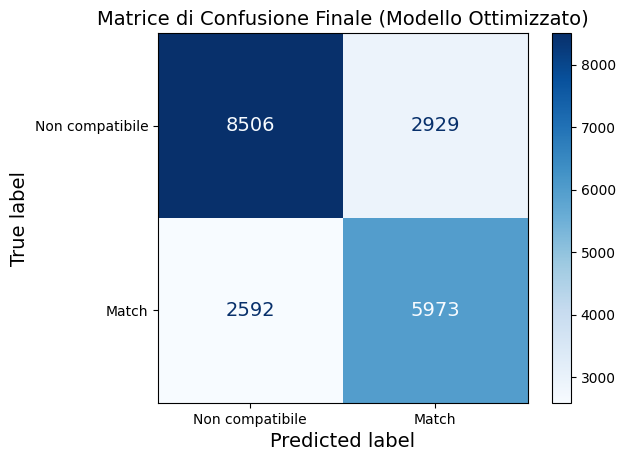

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

y_test_pred = best_model.predict(X_test)

f1_final = f1_score(y_test, y_test_pred)
print(f"F1-Score finale sul Test Set: {f1_final:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non compatibile", "Match"]).plot(cmap="Blues")
plt.title("Matrice di Confusione Finale (Modello Ottimizzato)")
plt.show()

**Cosa abbiamo ottenuto:** un F1-Score finale di circa **0.68** sul Test Set,
superiore anche al già buono 0.64 ottenuto in Cross Validation.


## 11. Curve Precision/Recall

Finora abbiamo sempre usato la soglia di decisione predefinita (0.5): se la
probabilità stimata di compatibilità supera 0.5, il modello dice "compatibile",
altrimenti "non compatibile". Ma questa soglia si può cambiare, a seconda di cosa ci
interessa di più: essere molto sicuri quando diciamo "compatibile" (precisione alta)
oppure non perdere nessuna coppia potenzialmente valida (recall alto).

Per esplorare questo compromesso, otteniamo prima le probabilità stimate dal modello
(invece delle sole etichette 0/1), poi calcoliamo precisione e recall al variare
della soglia.

In [ ]:
# Otteniamo le probabilità stimate sul Training Set (tramite cross validation)
y_probas = cross_val_predict(best_model, X_train, y_train, cv=3, method="predict_proba")

# Teniamo solo la probabilità della classe positiva ("compatibile")
y_scores = y_probas[:, 1]

print("Prime 5 probabilità di compatibilità stimate:")
print(y_scores[:5])

Prime 5 probabilità di compatibilità stimate:
[0.75497377 0.33890199 0.15374    0.45194992 0.49244656]


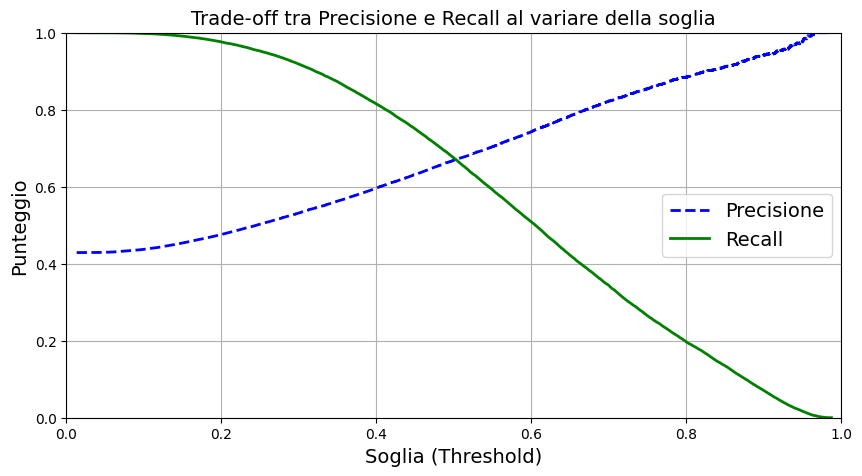

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisione", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Soglia (Threshold)")
plt.ylabel("Punteggio")
plt.title("Trade-off tra Precisione e Recall al variare della soglia")
plt.legend(loc="center right")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

**Cosa abbiamo ottenuto:** il grafico mostra chiaramente il compromesso: quando
alziamo la soglia, la precisione sale (il modello diventa più "esigente" e si sbaglia
meno quando dice "compatibile"), ma il recall scende (il modello individua sempre meno
coppie compatibili reali). Non esiste una soglia "giusta" in assoluto: la scelta
dipende da cosa conta di più per l'uso finale del modello.

### Cosa cambia se fissiamo la precisione minima al 70%

Quando il sistema segnala una coppia come compatibile, vogliamo avere ragione almeno 7 volte su
10. Cerchiamo quindi la soglia più bassa che garantisce questa precisione, e
osserviamo quale recall ne deriva.

In [ ]:
import numpy as np

precisione_desiderata = 0.70

# Cerchiamo il primo indice in cui la precisione raggiunge il valore desiderato
idx_threshold_ottimo = np.argmax(precisions >= precisione_desiderata)
threshold_ottimo = thresholds[idx_threshold_ottimo]
recall_associato = recalls[idx_threshold_ottimo]

print(f"Per ottenere una precisione del {precisione_desiderata*100:.0f}%, la soglia deve essere: {threshold_ottimo:.4f}")
print(f"Con questa soglia, il recall sarebbe solo del {recall_associato*100:.2f}% (percentuale di coppie realmente compatibili individuate)")

Per ottenere una precisione del 70%, la soglia deve essere: 0.5445
Con questa soglia, il recall sarebbe solo del 60.10% (percentuale di coppie realmente compatibili individuate)


**Cosa abbiamo ottenuto:** per arrivare al 70% di precisione basta alzare la soglia
fino a circa **0.54**, e il recall resta comunque alto, intorno al **60%**. Questo è
un risultato molto migliore rispetto alla versione con i valori grezzi (dove per
arrivare al 70% di precisione il recall crollava al 14%): con le nuove variabili di
differenza, il modello riesce a essere allo stesso tempo preciso e a individuare la
maggior parte delle coppie realmente compatibili, senza dover sacrificare molto
l'una per l'altra.


## 12. Confronto con una Rete Neurale (MLP)

Proviamo ora un secondo tipo di modello, un **Multi-Layer Perceptron** (una rete neurale),
per vedere se riesce a cogliere meglio eventuali relazioni non lineari
tra le variabili. Costruiamo una pipeline analoga a quella del Random Forest,
riutilizzando lo stesso preprocessing, e calcoliamo le probabilità stimate sul
Training Set con la stessa procedura di cross validation usata sopra, così da poter
confrontare le curve dei due modelli.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

print("Calcolo delle probabilità del MLP sul Training Set (cross validation)...")
y_probas_mlp = cross_val_predict(mlp_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_mlp = y_probas_mlp[:, 1]
print("Fatto.")

Calcolo delle probabilità del MLP sul Training Set (cross validation)...
Fatto.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


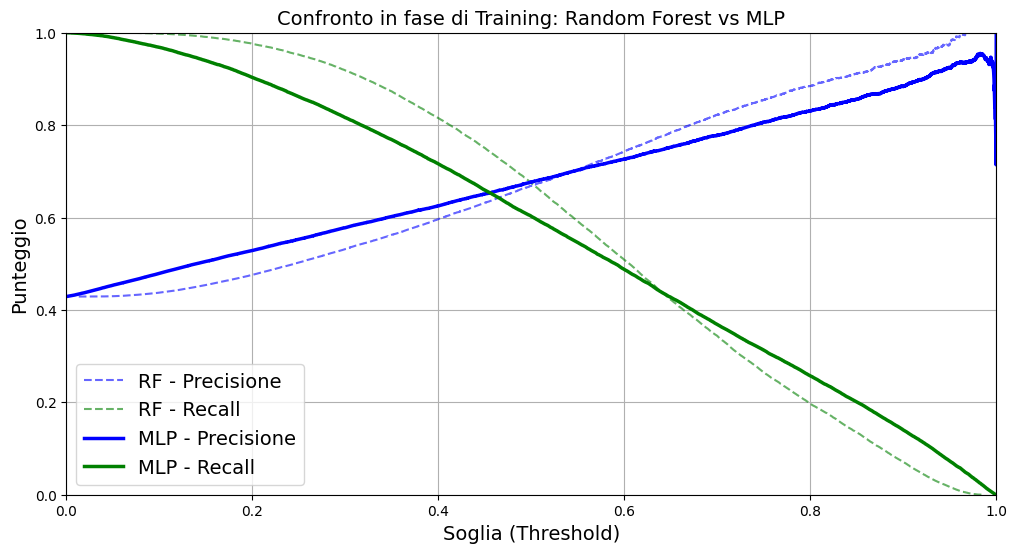

In [ ]:
precisions_mlp, recalls_mlp, thresholds_mlp = precision_recall_curve(y_train, y_scores_mlp)

plt.figure(figsize=(12, 6))

# Curve del Random Forest ottimizzato (linee tratteggiate)
plt.plot(thresholds, precisions[:-1], "b--", label="RF - Precisione", alpha=0.6)
plt.plot(thresholds, recalls[:-1], "g--", label="RF - Recall", alpha=0.6)

# Curve del nuovo MLP (linee continue)
plt.plot(thresholds_mlp, precisions_mlp[:-1], "b-", label="MLP - Precisione", linewidth=2.5)
plt.plot(thresholds_mlp, recalls_mlp[:-1], "g-", label="MLP - Recall", linewidth=2.5)

plt.xlabel("Soglia (Threshold)")
plt.ylabel("Punteggio")
plt.title("Confronto in fase di Training: Random Forest vs MLP")
plt.legend(loc="lower left")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

**Cosa abbiamo ottenuto:** guardando le curve sul Training Set, l'MLP mostra un
comportamento leggermente diverso da quello del Random Forest lungo le varie soglie.
Questo da solo non basta per dire quale modello sia migliore: la risposta definitiva
arriva solo confrontando i due modelli sul Test Set. Prima di arrivare a quel
confronto, però, ottimizziamo anche gli iperparametri dell'MLP (finora usato con una
configurazione scelta a mano), così il confronto finale sarà equo tra i due modelli.


## 12bis. Ottimizzazione degli Iperparametri dell'MLP (GridSearchCV)

Finora l'MLP è stato usato con una configurazione scelta a mano
(`hidden_layer_sizes=(64, 32)`, `max_iter=300`), e in fase di addestramento abbiamo
persino ricevuto un avviso (`ConvergenceWarning`) che segnala che il modello non ha
fatto in tempo a convergere del tutto entro le 300 iterazioni. Confrontarlo così com'è
con un Random Forest già ottimizzato con `GridSearchCV` non sarebbe un confronto
equo.

Applichiamo quindi anche all'MLP una ricerca sistematica degli iperparametri,
usando lo stesso campione ridotto del 15% già usato per il Random Forest (per
velocizzare la ricerca) e aumentando il numero massimo di iterazioni, così da dargli
la possibilità di convergere davvero.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Griglia di iperparametri per l'MLP: proviamo architetture e regolarizzazioni diverse
param_grid_mlp = {
    "classifier__hidden_layer_sizes": [(64, 32), (100, 50), (128, 64, 32)],
    "classifier__alpha": [0.0001, 0.001, 0.01]
}

mlp_pipeline_grid = Pipeline([
    ("prep", preprocessing),
    ("classifier", MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=800,
        random_state=42
    ))
])

grid_search_mlp = GridSearchCV(
    mlp_pipeline_grid,
    param_grid_mlp,
    cv=3,
    scoring="f1",
    verbose=1,
    n_jobs=1
)

print("Ricerca della configurazione migliore per l'MLP in corso...")
grid_search_mlp.fit(X_train_sample, y_train_sample)

best_mlp_model = grid_search_mlp.best_estimator_
print(f"Configurazione vincente per l'MLP: {grid_search_mlp.best_params_}")
print(f"F1-Score (Cross Validation, sul campione) della configurazione vincente: {grid_search_mlp.best_score_:.4f}")


Ricerca della configurazione migliore per l'MLP in corso (può richiedere qualche minuto)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Configurazione vincente per l'MLP: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (64, 32)}
F1-Score (Cross Validation, sul campione) della configurazione vincente: 0.5903


**Cosa abbiamo ottenuto:** `GridSearchCV` ha selezionato `alpha=0.001` con
`hidden_layer_sizes=(64, 32)` — la stessa architettura che avevamo scelto a mano in
partenza — ottenendo un F1-Score di **0.59** in Cross Validation sul campione
ridotto.

D'ora in avanti, nel confronto finale usiamo `best_mlp_model` (la versione
ottimizzata) al posto della versione con i parametri scelti a mano, così il confronto
con il Random Forest ottimizzato è equo per entrambi i modelli.


## 13. Valutazione Finale Comparativa: Random Forest vs MLP

Confrontiamo ora davvero i due modelli sul Test Set (dati mai visti), usando
entrambi nella loro versione ottimizzata: `best_model` (Random Forest, ottimizzato
con `GridSearchCV`) e `best_mlp_model` (MLP, ottimizzato anch'esso con
`GridSearchCV` nel passaggio precedente).

Per scegliere la soglia di decisione in modo equo per entrambi, invece di sceglierla
"a occhio" osservando il grafico, cerchiamo automaticamente il punto in cui, per
ciascun modello, precisione e recall si incrociano (cioè sono il più possibile
vicini tra loro) sul Training Set.

Soglia scelta per il Random Forest: 0.5026
Soglia scelta per l'MLP:            0.4483

--- VALUTAZIONE FINALE SUL TEST SET ---
Random Forest (soglia 0.50):
  Precisione: 0.6721
  Recall:     0.6929
  F1-Score:   0.6823

MLP / Rete Neurale ottimizzato (soglia 0.45):
  Precisione: 0.6411
  Recall:     0.7192
  F1-Score:   0.6779



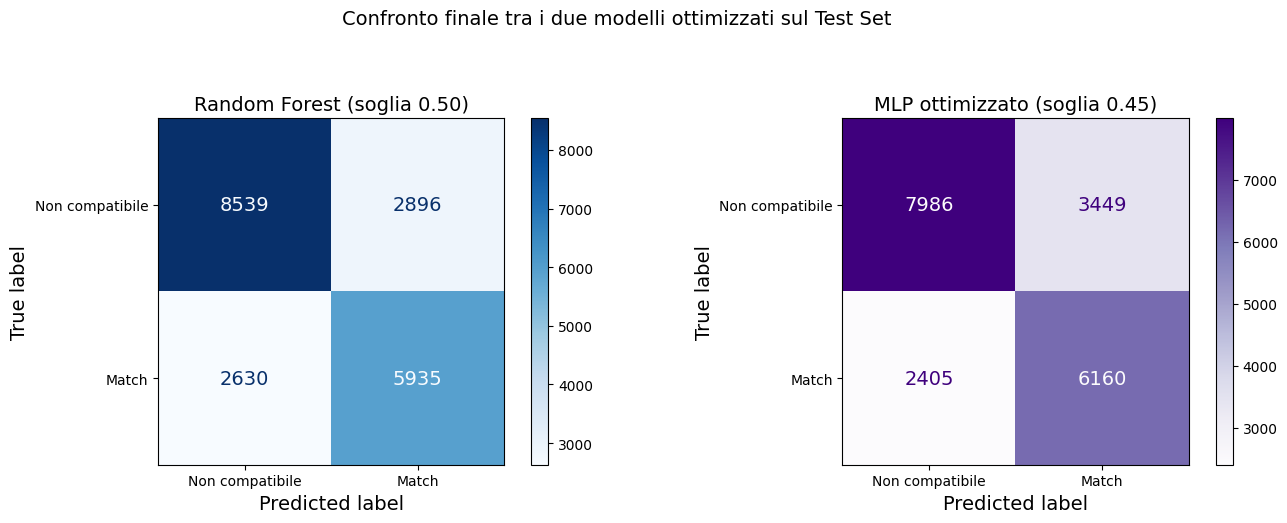

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# --- Troviamo la soglia di incrocio Precisione/Recall per il Random Forest (già calcolata sopra: precisions, recalls, thresholds) ---
idx_incrocio_rf = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))
soglia_rf = thresholds[idx_incrocio_rf]

# --- Calcoliamo le stesse curve per l'MLP ottimizzato, sul Training Set ---
y_probas_best_mlp = cross_val_predict(best_mlp_model, X_train, y_train, cv=3, method="predict_proba")
y_scores_best_mlp = y_probas_best_mlp[:, 1]

precisions_best_mlp, recalls_best_mlp, thresholds_best_mlp = precision_recall_curve(y_train, y_scores_best_mlp)
idx_incrocio_mlp = np.argmin(np.abs(precisions_best_mlp[:-1] - recalls_best_mlp[:-1]))
soglia_mlp = thresholds_best_mlp[idx_incrocio_mlp]

print(f"Soglia scelta per il Random Forest: {soglia_rf:.4f}")
print(f"Soglia scelta per l'MLP:            {soglia_mlp:.4f}")

# =======================================================
# 1. RANDOM FOREST OTTIMIZZATO
# =======================================================
probas_test_rf = best_model.predict_proba(X_test)[:, 1]
y_test_pred_rf = (probas_test_rf >= soglia_rf)

# =======================================================
# 2. MLP OTTIMIZZATO (best_mlp_model trovato con GridSearchCV)
# =======================================================
best_mlp_model.fit(X_train, y_train)  # lo alleniamo sull'intero Training Set
probas_test_mlp = best_mlp_model.predict_proba(X_test)[:, 1]
y_test_pred_mlp = (probas_test_mlp >= soglia_mlp)

# =======================================================
# 3. METRICHE COMPARATIVE SUL TEST SET
# =======================================================
print("\n--- VALUTAZIONE FINALE SUL TEST SET ---")
print(f"Random Forest (soglia {soglia_rf:.2f}):")
print(f"  Precisione: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"  Recall:     {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"  F1-Score:   {f1_score(y_test, y_test_pred_rf):.4f}\n")

print(f"MLP / Rete Neurale ottimizzato (soglia {soglia_mlp:.2f}):")
print(f"  Precisione: {precision_score(y_test, y_test_pred_mlp):.4f}")
print(f"  Recall:     {recall_score(y_test, y_test_pred_mlp):.4f}")
print(f"  F1-Score:   {f1_score(y_test, y_test_pred_mlp):.4f}\n")

# =======================================================
# 4. MATRICI DI CONFUSIONE IN PARALLELO
# =======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non compatibile", "Match"]).plot(
    ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title(f"Random Forest (soglia {soglia_rf:.2f})")

cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=["Non compatibile", "Match"]).plot(
    ax=axes[1], cmap="Purples", values_format="d"
)
axes[1].set_title(f"MLP ottimizzato (soglia {soglia_mlp:.2f})")

plt.suptitle("Confronto finale tra i due modelli ottimizzati sul Test Set", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


**Cosa abbiamo ottenuto:** ora che il Random Forest viene riaddestrato sull'intero
Training Set (e non solo sul campione ridotto usato da `GridSearchCV`), il confronto
cambia rispetto alla versione precedente:

| Modello | Soglia | Precisione | Recall | F1-Score |
|---|---|---|---|---|
| **Random Forest (ottimizzato)** | 0.50 | 0.6721 | 0.6929 | **0.6823** |
| MLP (ottimizzato) | 0.45 | 0.6411 | **0.7192** | 0.6779 |

Random Forest vince, anche se di pochissimo (0.682 contro
0.678). L'MLP mantiene un recall più alto (individua una quota leggermente maggiore
delle coppie realmente compatibili), ma il Random Forest è complessivamente più
equilibrato tra precisione e recall, il che gli dà un F1-Score leggermente migliore.

Questo risultato conferma quanto discusso in precedenza: il vantaggio che l'MLP
sembrava avere prima non era dovuto a una superiorità reale del modello, ma al fatto
che il Random Forest non stava sfruttando tutti i dati di addestramento disponibili.
Una volta corretto questo problema, i due modelli tornano a essere praticamente alla
pari, con un lieve vantaggio per il Random Forest — un risultato coerente con
l'aspettativa generale che, su dati tabulari con relativamente poche variabili ben
costruite (come le nostre variabili di differenza), i modelli ad albero tendono a
essere competitivi con le reti neurali, se non leggermente migliori.

**Conclusione generale del progetto:** il cambiamento più importante di questo
progetto non è stato scegliere tra Random Forest e MLP, ma **come rappresentare i
dati**: passare dai valori grezzi di Persona A e Persona B alle loro differenze e
somiglianze ha portato il F1-Score da circa 0.49 a circa 0.64 in Cross Validation.
Abbiamo verificato che aggiungere anche i valori grezzi non migliora questo
risultato (F1 = 0.62, leggermente peggiore), confermando che la relazione tra i due
partner conta più della loro identità individuale.

Confrontando poi i due modelli in modo equo — entrambi ottimizzati con
`GridSearchCV` e, soprattutto, entrambi riaddestrati sull'intero Training Set prima
della valutazione finale — otteniamo un F1-Score sul Test Set di **0.68** per il
Random Forest e di **0.68** per l'MLP: risultati praticamente identici, con un
minimo vantaggio per il Random Forest. Questo indica che, per questo problema e con
queste variabili, la scelta tra un modello ad alberi e una rete neurale conta molto
meno di due altri fattori: come sono state costruite le variabili di input, e
assicurarsi che ciascun modello sia addestrato correttamente su tutti i dati
disponibili.

Alcuni limiti da tenere presente e possibili miglioramenti futuri:
- la griglia di iperparametri usata sia per il Random Forest sia per l'MLP è
  volutamente ridotta per contenere i tempi di calcolo: una ricerca più ampia
  potrebbe migliorare ulteriormente entrambi i modelli;
- la soglia di decisione è scelta automaticamente in base al punto di incrocio tra
  precisione e recall, ma resta comunque una scelta tra diversi criteri possibili
  (ad esempio, si potrebbe invece massimizzare direttamente l'F1-Score)